In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# Set seeds
def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

set_seeds()

In [4]:
# 0. Import necessary modules
from transformers import AutoModelForImageClassification, AutoTokenizer

# 1. Get pretrained weights for ViT-Base from Hugging Face
pretrained_vit_weights = "google/vit-base-patch32-384"

# 2. Setup a ViT model instance with pretrained weights from Hugging Face
pretrained_vit = AutoModelForImageClassification.from_pretrained(pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.base_model.parameters():
    parameter.requires_grad = False

# 4. Change the number of output classes
class_names = ['mutu1', 'mutu2', 'mutu3', 'mutu4', 'mutu5', 'mutu6']
pretrained_vit.classifier = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

# Set the model to evaluation mode
pretrained_vit.eval()

# 5. Define the transforms for your dataset
transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

# Let's make Prediction:

In [5]:
import os

pred_class_path = '/kaggle/input/prediction-arabica-class/pred_class'
pred_list = []

for root, dirs, files in os.walk(pred_class_path):
    for file in files:
        if file.endswith('.jpg'):
            pred_list.append((os.path.join(root, file), class_names.index(root.split('/')[-1])))

pred_list.sort(key=lambda x: x[1])
pred_list = [item[0] for item in pred_list]

In [6]:
# Load the model weights
model_weights = torch.load('/kaggle/input/vit-arabica-weight/weight_vit/vit-hgfc-32(5050).pth')

# Create a model instance and load the weights into it
model = pretrained_vit
model.load_state_dict(model_weights)

<All keys matched successfully>

In [7]:
import itertools

actual_labels = [name for name in itertools.chain.from_iterable(itertools.repeat(class_name, 10) for class_name in class_names)]

In [8]:
def predict_image(image_path, model, class_names):
    # Load the image
    image = Image.open(image_path)

    # Define transformations to be applied to the image
    transform = transforms.Compose([
        transforms.Resize((384, 384)),  # Resize the image to the expected input size of the model
        transforms.ToTensor(),           # Convert the image to a PyTorch tensor
        transforms.Normalize(            # Normalize the image
            mean=[0.485, 0.456, 0.406],   # Mean and standard deviation values for ImageNet dataset
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Apply the transformations to the image
    input_image = transform(image).unsqueeze(0)  # Add batch dimension

    # Set the device to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move the input tensor to the device
    input_image = input_image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Perform inference
    with torch.no_grad():
        outputs = model(input_image)

    # Get the logits from the output object
    logits = outputs.logits

    # Apply softmax to get probabilities
    probabilities = torch.softmax(logits, dim=1)

    # Get the predicted class index
    predicted_class_idx = torch.argmax(probabilities).item()

    # Get the class label corresponding to the predicted index
    predicted_class_label = class_names[predicted_class_idx]

    # Get the probability score for the predicted class
    predicted_probability = probabilities[0, predicted_class_idx].item()
    
    # Get predicted labels
    predicted_labels.append(predicted_class_label)


In [9]:
from PIL import Image

# Get predicted labels
predicted_labels = []
    
# Get prediction images    
image_paths = pred_list

# Iterate over the images and make predictions
for image_path in image_paths:
    predict_image(image_path, model, class_names)

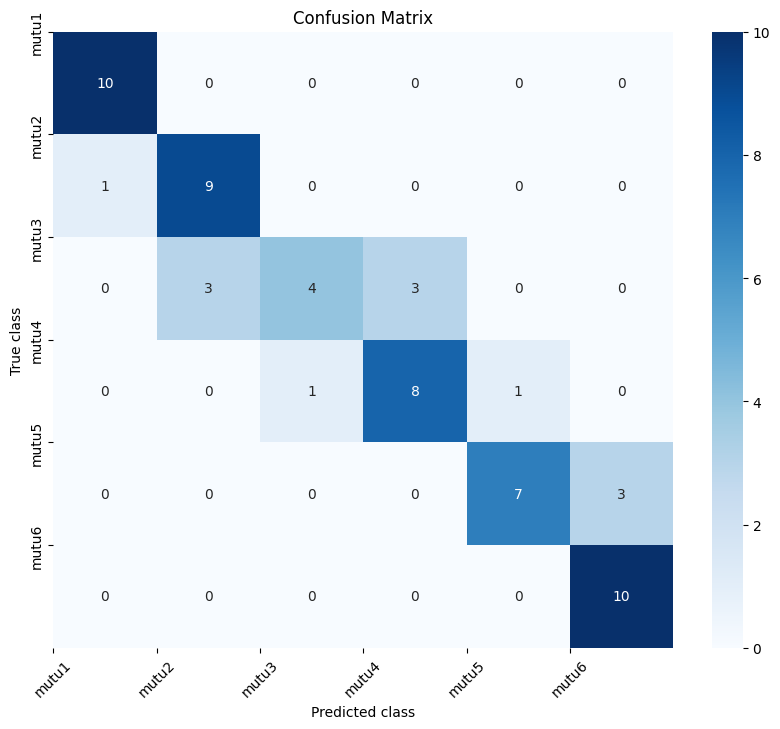

In [10]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_confusion_matrix(actual_labels, predicted_labels):
    cm = confusion_matrix(actual_labels, predicted_labels)
    return cm

confusion_matrix_data = calculate_confusion_matrix(actual_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_data, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.show()

In [11]:
accuracy = np.trace(confusion_matrix_data) / np.sum(confusion_matrix_data)
precision = np.diag(confusion_matrix_data) / np.sum(confusion_matrix_data, axis=0)
recall = np.diag(confusion_matrix_data) / np.sum(confusion_matrix_data, axis=1)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Accuracy: 0.8
Precision: [0.90909091 0.75       0.8        0.72727273 0.875      0.76923077]
Recall: [1.  0.9 0.4 0.8 0.7 1. ]
F1 Score: [0.95238095 0.81818182 0.53333333 0.76190476 0.77777778 0.86956522]
